# Leakage Experiment

This notebook is the report surface for the leakage experiment. Shared SQL and model logic lives in `src/pit_feature_store/leakage.py`; this notebook imports that logic, renders charts, validates the approved metrics, and exports report artifacts.

## Experiment Contract

- PIT features use `[cutoff - window, cutoff)`.
- Future-only features use `(cutoff, cutoff + window]` with the same feature names and windows as PIT.
- `pit_plus_future` keeps PIT features and appends explicitly named future features.
- Train/test split is temporal, not random, and rows with the same timestamp stay on the same side of the split.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)


project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src' / 'pit_feature_store').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pit_feature_store.leakage import run_experiment

database_path = project_root / 'warehouse.duckdb'
catalog_path = project_root / 'config' / 'feature_catalog.yaml'
report_dir = project_root / 'artifacts' / 'reports'
metrics_path = report_dir / 'leakage_metrics.csv'
markdown_path = report_dir / 'leakage_experiment.md'

database_path, catalog_path, metrics_path, markdown_path

(WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/warehouse.duckdb'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/config/feature_catalog.yaml'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/reports/leakage_metrics.csv'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/reports/leakage_experiment.md'))

## Run Experiment

The module returns metrics and prediction scores without printing or plotting. The notebook owns display and artifact export.

In [2]:
experiment = run_experiment(database_path=database_path, catalog_path=catalog_path)
metrics = experiment['metrics']
predictions = experiment['predictions']
report_markdown = experiment['markdown']

display(metrics)
metrics[['dataset', 'roc_auc', 'pr_auc', 'pr_auc_lift']]

,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,pit,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.679783,0.067894,1.992364
1,future_only,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.674214,0.064931,1.905402
2,pit_plus_future,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.034077,8,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.705485,0.074536,2.187256


,dataset,roc_auc,pr_auc,pr_auc_lift
0,pit,0.679783,0.067894,1.992364
1,future_only,0.674214,0.064931,1.905402
2,pit_plus_future,0.705485,0.074536,2.187256


## Metric Validation

The values below are compared with the approved Stage 4 result recorded in `STATUS.md`.

In [3]:
expected = {
    'pit': {'roc_auc': 0.679783, 'pr_auc': 0.067894},
    'future_only': {'roc_auc': 0.674214, 'pr_auc': 0.064931},
    'pit_plus_future': {'roc_auc': 0.705485, 'pr_auc': 0.074536},
}
indexed = metrics.set_index('dataset')
deltas = []
for dataset, expected_metrics in expected.items():
    for metric_name, expected_value in expected_metrics.items():
        actual_value = float(indexed.loc[dataset, metric_name])
        delta = actual_value - expected_value
        deltas.append(
            {
                'dataset': dataset,
                'metric': metric_name,
                'expected': expected_value,
                'actual': actual_value,
                'delta': delta,
            }
        )
        assert abs(delta) < 1e-6

delta_frame = pd.DataFrame(deltas)
display(delta_frame)
assert indexed.loc['pit', 'eligible_start'] == '2018-01-01 00:00:00'
assert indexed.loc['pit', 'eligible_end'] == '2018-05-02 23:58:51'
assert indexed.loc['pit', 'split_ts'] == '2018-04-05 23:19:56'
delta_frame

,dataset,metric,expected,actual,delta
0,pit,roc_auc,0.679783,0.679783,2.391022e-07
1,pit,pr_auc,0.067894,0.067894,3.276238e-07
2,future_only,roc_auc,0.674214,0.674214,2.657078e-08
3,future_only,pr_auc,0.064931,0.064931,-8.442102e-08
4,pit_plus_future,roc_auc,0.705485,0.705485,7.514388e-08
5,pit_plus_future,pr_auc,0.074536,0.074536,-2.984340e-07


,dataset,metric,expected,actual,delta
0,pit,roc_auc,0.679783,0.679783,2.391022e-07
1,pit,pr_auc,0.067894,0.067894,3.276238e-07
2,future_only,roc_auc,0.674214,0.674214,2.657078e-08
3,future_only,pr_auc,0.064931,0.064931,-8.442102e-08
4,pit_plus_future,roc_auc,0.705485,0.705485,7.514388e-08
5,pit_plus_future,pr_auc,0.074536,0.074536,-2.984340e-07


## ROC and PR Curves

The curves are drawn in the notebook from returned prediction scores. No charting code lives in the reusable module.

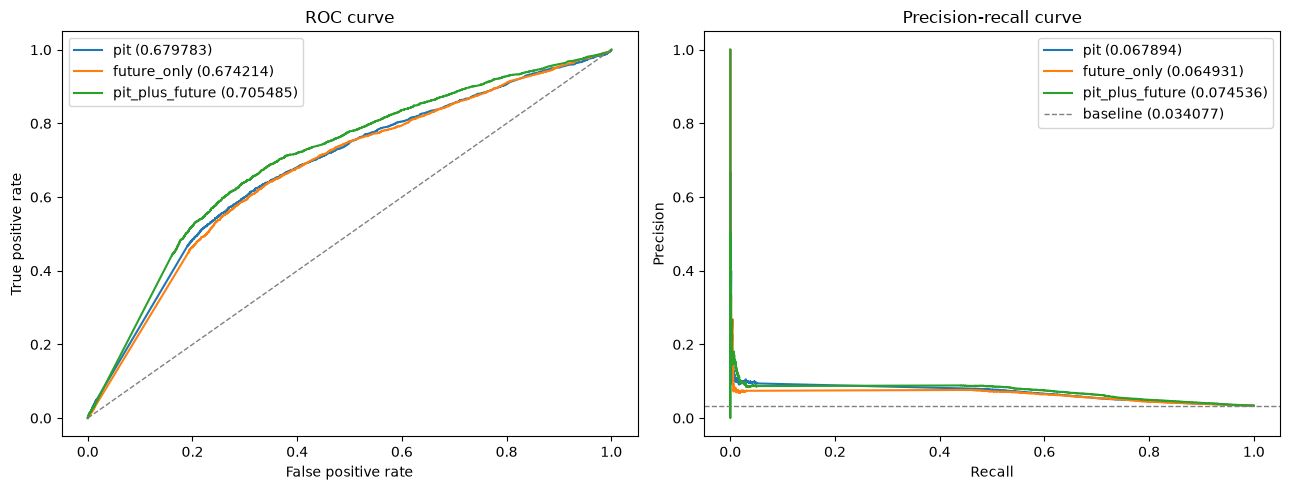

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for dataset_name, group in predictions.groupby('dataset', sort=False):
    metric_row = indexed.loc[dataset_name]
    fpr, tpr, _ = roc_curve(group['label'], group['score'])
    precision, recall, _ = precision_recall_curve(group['label'], group['score'])
    axes[0].plot(
        fpr,
        tpr,
        label=f"{dataset_name} ({metric_row['roc_auc']:.6f})",
    )
    axes[1].plot(
        recall,
        precision,
        label=f"{dataset_name} ({metric_row['pr_auc']:.6f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()

baseline = float(indexed.loc['pit', 'test_fraud_rate'])
axes[1].axhline(baseline, linestyle='--', color='gray', linewidth=1, label=f'baseline ({baseline:.6f})')
axes[1].set_title('Precision-recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

## Analysis Summary

The controlled comparison is `pit_plus_future` versus `pit`: the augmented model keeps the past-looking PIT features and receives additional future-looking features. In the approved run, this increases ROC-AUC and PR-AUC. The `future_only` comparison is useful but secondary because it replaces past signal with future signal instead of adding future signal to the same PIT base. The result is empirical: future information is not assumed to improve metrics before running the experiment.

## Export Artifacts

The report outputs are written under `artifacts/reports/`, independent of the later output migration task.

In [5]:
report_dir.mkdir(parents=True, exist_ok=True)
metrics.to_csv(metrics_path, index=False, float_format='%.10f')
markdown_path.write_text(report_markdown, encoding='utf-8')

roundtrip = pd.read_csv(metrics_path)
pd.testing.assert_frame_equal(roundtrip, metrics, check_dtype=False)

print(f'Wrote metrics: {metrics_path}')
print(f'Wrote markdown report: {markdown_path}')

Wrote metrics: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_metrics.csv
Wrote markdown report: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_experiment.md
